Este código foi criado para desenvolver um modelo de CNN para quantificar células marcadas com fluorescencia, indicando presença da proteína na célula.

In [ ]:
pip install util-gfsilveira

# Imports data structuring

In [ ]:
#organização dos arquivos
import os
#salvar/carregar arquivos em diferentes formatos
import joblib
#organizando os arquivos de forma aleatória
import random
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#gerar imagem
import matplotlib.image as mpimg

# CNN template import

In [ ]:
#modelo de revisão redes neurais - cnn
from keras.models import Sequential
from keras.utils import to_categorical # Import directly from keras.utils
from util import meus_uteis, timeProcess, mask_corr_graphic, printLis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

Documents from different files will be stored in this directory

In [ ]:
diretorio = '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia' #alimentando a variável com os arquivos da pasta datasets
lista_dados = os.listdir(diretorio) #listando os arquivos dessa pasta
printLis(lista_dados) #printando as diferentes listas

-------------
-=< Lista >=-
-------------
0 -> lista_img_100_resized_regre_cho745_2024-8-20.gz
1 -> lista_rotulo_100_resized_regre_cho745_2024-8-20.gz
2 -> lista_img_75_resized_regre_cho745_2024-8-20.gz
3 -> lista_rotulo_75_resized_regre_cho745_2024-8-20.gz
4 -> lista_img_50_resized_regre_cho745_2024-8-20.gz
5 -> lista_rotulo_50_resized_regre_cho745_2024-8-20.gz
6 -> lista_img_25_resized_regre_cho745_2024-8-20.gz
7 -> lista_rotulo_25_resized_regre_cho745_2024-8-20.gz


Lists of all images in each file

In [ ]:
#lstando arquivos com as imagens 100%, 75%, 50%, 25%
for k, v in enumerate(lista_dados):
    if k in [0,2,4,6]:
        print(f'{k} -> {v}')

0 -> lista_img_100_resized_regre_cho745_2024-8-20.gz
2 -> lista_img_75_resized_regre_cho745_2024-8-20.gz
4 -> lista_img_50_resized_regre_cho745_2024-8-20.gz
6 -> lista_img_25_resized_regre_cho745_2024-8-20.gz


## x = features/images

In [ ]:
#0 - 100% somando todas as imagens de diferentes tamanho
X_cem = joblib.load(diretorio+ '/' + lista_dados[0])

# 2 - 75%
X_setcin = joblib.load(diretorio+ '/' + lista_dados[2])

# 4 - 50%
X_cinq = joblib.load(diretorio+ '/' + lista_dados[4])

# 6 - 25%
X_vincin = joblib.load(diretorio+ '/' + lista_dados[6])

x = np.asarray(list(X_cem) + list(X_setcin) + list(X_cinq) + list(X_vincin))

x.shape

(640, 300, 300, 3)

# y = labels

Opening the labels that were saved in the preparation of the images

In [ ]:
for k, v in enumerate(lista_dados):
    if k in [1,3,5,7]:
        print(f'{k} -> {v}')

1 -> lista_rotulo_100_resized_regre_cho745_2024-8-20.gz
3 -> lista_rotulo_75_resized_regre_cho745_2024-8-20.gz
5 -> lista_rotulo_50_resized_regre_cho745_2024-8-20.gz
7 -> lista_rotulo_25_resized_regre_cho745_2024-8-20.gz


In [ ]:
#1 - 100% somando todos os rótulos de diferentes tamanho
y_cem = joblib.load(diretorio+ '/' + lista_dados[1])

#3 - 75%
y_setcin = joblib.load(diretorio+ '/' + lista_dados[3])

#4 - 50%
y_cinq = joblib.load(diretorio+ '/' + lista_dados[5])

#7 - 25%
y_vincin = joblib.load(diretorio+ '/' + lista_dados[7])

y = np.asarray(list(y_cem) + list(y_setcin) + list(y_cinq) + list(y_vincin))

y.shape

(640,)

#Separando dados de validação

In [ ]:
#Train and test split datasets for CNN model
#função que separa as imagens em teste e treino
from sklearn.model_selection import train_test_split

10% dos 640 - foram separados para validação do modelo.

In [ ]:
zeros = list(np.zeros(576))
ones = list(np.ones(64))
lista = np.array(zeros + ones)
#lista

In [ ]:
random.shuffle(lista)
lista_valida = [True if i == 1 else False for i in lista]
lista_treino_test = [False if i == 1 else True for i in lista]
#np.array(lista_valida)

In [ ]:
#imagens
x_valida = x[lista_valida]
x_treino_test = x[lista_treino_test]

print(x_valida.shape)
print(x_treino_test.shape)

(64, 300, 300, 3)
(576, 300, 300, 3)


In [ ]:
#rótulos
y_valida = y[lista_valida]
y_treino_test = y[lista_treino_test]

print(y_valida.shape)
print(y_treino_test.shape)

(64,)
(576,)


In [ ]:
data = timeProcess()[1]
#Salvando 10$ das imagens para validação
joblib.dump(x_valida, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/imagens_validação_10%_fluore_'+data+'.gz')
joblib.dump(y_valida, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/rótulos_validação_10%_fluore_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/rótulos_validação_10%_fluore_2024-8-22.gz']

Test and training separation from a library.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_treino_test, y_treino_test, test_size=0.3, random_state=0)
#variáveis recebem o número de imagens para tes e treino
print(f'{X_train.shape} \n{X_test.shape} \n{y_train.shape} \n{y_test.shape}')

(403, 300, 300, 3) 
(173, 300, 300, 3) 
(403,) 
(173,)


In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)
# print(int_array)
# print(int_array.dtype)


In [ ]:
#salvando os resultados de treino e teste
# joblib.dump(X_train, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/1_images_de_X_train_fluor_melhor_modelo_200_epochs_90%_'+data+'.gz')
# joblib.dump(y_train, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/2_rotulos_de_y_train_fluor_melhor_modelo_200_epochs_90%_'+data+'.gz')
# joblib.dump(X_test, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/3_images_de_X_test_fluor_melhor_modelo_200_epochs_90%_'+data+'.gz')
# joblib.dump(y_test, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/4_rotulos_de_y_test_fluor_melhor_model_200_epochs_90%_'+data+'.gz')

### Model determination

In [ ]:
modelo = Sequential()
modelo.add(Conv2D(32, kernel_size=3, activation='relu', input_shape=X_train[0].shape))
#função de ativação relu é muito utilizado para problemas de regressão
modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
modelo.add(Conv2D(64, kernel_size=3, activation='relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
modelo.add(Conv2D(128, kernel_size=3, activation='relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
modelo.add(Conv2D(256, kernel_size=3, activation='relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
modelo.add(Flatten())
modelo.add(Dropout(0.2))
modelo.add(Dense(1, activation='linear'))
#apenas uma saída e de forma linear
modelo.compile(optimizer='adam', loss='mse', metrics=['mean_squared_error'])
print(modelo.summary())

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 33, 33, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          65,537 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 453,953 (1.73 MB)

 Trainable params: 453,953 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

None


# Training and testing epochs

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# simple early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=18)

In [ ]:
# fit model
history = modelo.fit(X_train,y_train,
                    validation_data=(X_test, y_test),
                    epochs=200, verbose=2,
                    callbacks=[es]
                     )

Epoch 1/200
13/13 - 30s - 2s/step - loss: 11262.5459 - mean_squared_error: 11262.5459 - val_loss: 1546.3610 - val_mean_squared_error: 1546.3610
Epoch 2/200
13/13 - 15s - 1s/step - loss: 1966.8296 - mean_squared_error: 1966.8296 - val_loss: 1548.8293 - val_mean_squared_error: 1548.8293
Epoch 3/200
13/13 - 1s - 87ms/step - loss: 1442.5532 - mean_squared_error: 1442.5532 - val_loss: 1091.8475 - val_mean_squared_error: 1091.8475
Epoch 4/200
13/13 - 1s - 96ms/step - loss: 1147.2592 - mean_squared_error: 1147.2592 - val_loss: 717.2568 - val_mean_squared_error: 717.2568
Epoch 5/200
13/13 - 1s - 98ms/step - loss: 836.4100 - mean_squared_error: 836.4100 - val_loss: 559.6592 - val_mean_squared_error: 559.6592
Epoch 6/200
13/13 - 1s - 96ms/step - loss: 689.0297 - mean_squared_error: 689.0297 - val_loss: 523.1018 - val_mean_squared_error: 523.1018
Epoch 7/200
13/13 - 1s - 98ms/step - loss: 726.0566 - mean_squared_error: 726.0566 - val_loss: 467.4573 - val_mean_squared_error: 467.4573
Epoch 8/200
1

## Accuracy Assessment

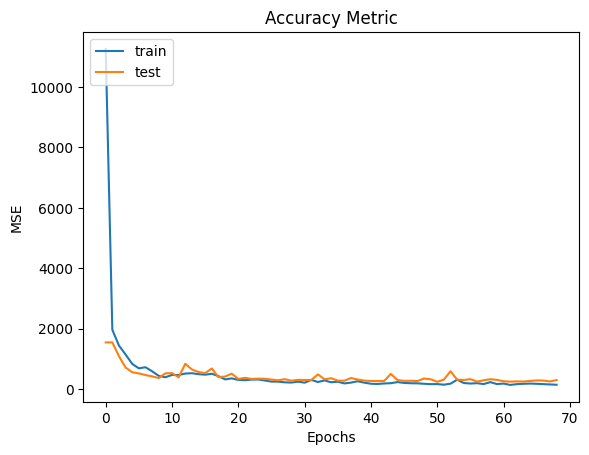

In [ ]:
#gráfico avaliando a acurácia a partir de treino e teste
plt.plot(history.history['mean_squared_error'])
plt.plot(history.history['val_mean_squared_error'])
plt.title('Accuracy Metric')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


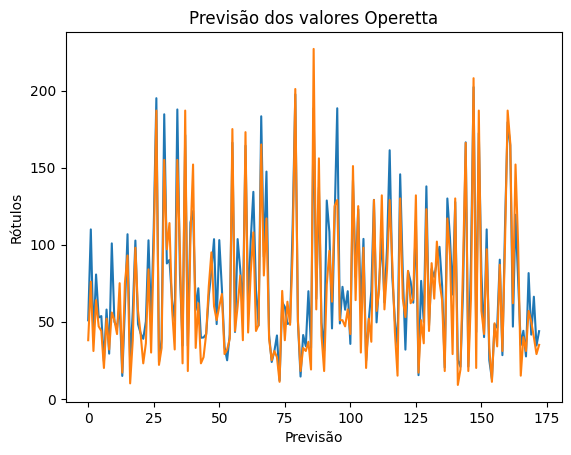

In [ ]:
#avaliando a previsão do modelo com os rótulos
prev = modelo.predict(X_test)
plt.title('Previsão dos valores Operetta')
plt.ylabel('Rótulos')
plt.xlabel('Previsão')
plt.plot(prev)#azul - o que o modelo previu
plt.plot(y_test)#laranja - o que se sabe - observado
plt.show()

In [ ]:
# Qualit model analisys
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error

In [ ]:
#buscando pelas métricas
print(f"{round(r2_score(y_test, prev) * 100, 2)}% r2_score") #raíz quadrada
print(f"{round(mean_absolute_error(y_test, prev), 2)} Erro médio absoluto")
print(f"{round(mean_squared_error(y_test, prev), 2)} Erro médio quadrático") #erro médio quadrático
# print(f"{round(median_absolute_error(y_test, prev), 2)}")#Erro médio absoluto sem %
#print(f"{round(median(y_test, prev), 2)} mediana") #erro médio quadrático

86.48% r2_score
13.26 Erro médio absoluto
302.32 Erro médio quadrático


In [ ]:
modelo.save('/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/modelo_fluore_100_75_50_25_'+data+'.keras')